#### Base de dados (tabela DN)
https://datasus.saude.gov.br/transferencia-de-arquivos


<h1 align="center">Predição do peso ao nascer em Minas Gerais utilizando modelos de regressão a partir dos dados da SINASC</h1>

---

## Problema

Predizer o risco de baixo peso ao nascer (<2500g) em nascidos vivos em Minas Gerais no período de 2020-2024, utilizando dados socioeconômicos e clínicos disponíveis até o momento do parto com dados da base SINASC da tabela DN.  

É um problema de regressão, com base clínica sólida na literatura (fator de risco reconhecido para mortalidade neonatal), desbalanceamento de classes (~8-10% de baixo peso no Brasil).

## Escopo

| Parâmetro | Definição |
|---|---|
| **Fonte** | SINASC (tabela DN)
| **UF** | Minas Gerais (MG) |
| **Período** | 2020–2024 (5 anos) |
| **Unidade de análise** | 1 registro = 1 nascido vivo |
| **Target** | `PESO < 2500`|

---

### Importando bibliotecas

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
import os

# Feature engenering
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Metricas
from sklearn.metrics import mean_absolute_error, r2_score,  mean_squared_error, average_precision_score, precision_recall_curve
from scipy import stats

# Otimização de hiperparametros
import optuna
from optuna.samplers import TPESampler

### Lendo os arquivos

In [2]:
# Todos os arquivos csv da pasta data
arquivos_csv = [f for f in os.listdir('data') if f.endswith('.csv')]

dfs = []
for arquivo in arquivos_csv:
    path = os.path.join('data', arquivo)
    df = pd.read_csv(path)
    df['origem'] = arquivo
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

C:\Users\Max\AppData\Local\Temp\ipykernel_12984\3530333382.py:7: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR,origem
0,1,2495228.0,110028,1,19,2.0,4.0,621005.0,1.0,3.0,...,12012020.0,6.0,0,1,1,11,1,4,10480,DNMG2020.csv
1,1,2456613.0,210530,1,21,1.0,5.0,999991.0,0.0,0.0,...,1022020.0,7.0,0,1,1,2,0,2,169378,DNMG2020.csv
2,1,2456893.0,211130,1,29,1.0,5.0,999991.0,1.0,1.0,...,NaN,7.0,0,1,1,3,1,5,194775,DNMG2020.csv
3,1,6553567.0,211230,1,32,2.0,4.0,621005.0,1.0,0.0,...,10042020.0,5.0,0,1,1,5,1,5,198579,DNMG2020.csv
4,1,2319454.0,260790,1,25,1.0,4.0,999992.0,1.0,0.0,...,7012020.0,12.0,0,1,1,5,1,2,357523,DNMG2020.csv


In [3]:
# Filtrandos as features que serão utilizadas
filtro = ['IDADEMAE', 
          'ESTCIVMAE', 
          'ESCMAE2010', 
          'QTDFILVIVO', 
          'QTDFILMORT', 
          'QTDGESTANT', 
          'QTDPARTNOR', 
          'QTDPARTCES', 
          'PARIDADE', 
          'GRAVIDEZ', 
          'SEMAGESTAC', 
          'KOTELCHUCK', 
          'CONSPRENAT', 
          'MESPRENAT', 
          'SEXO', 
          'DTNASC',
          'PESO'] # <- Target

df = df[filtro]

In [4]:
# Sumario das variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178134 entries, 0 to 1178133
Data columns (total 17 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   IDADEMAE    1178134 non-null  int64  
 1   ESTCIVMAE   1172467 non-null  float64
 2   ESCMAE2010  1169266 non-null  float64
 3   QTDFILVIVO  1166936 non-null  float64
 4   QTDFILMORT  1163351 non-null  float64
 5   QTDGESTANT  1164011 non-null  float64
 6   QTDPARTNOR  1161668 non-null  float64
 7   QTDPARTCES  1161530 non-null  float64
 8   PARIDADE    1178134 non-null  int64  
 9   GRAVIDEZ    1177452 non-null  float64
 10  SEMAGESTAC  1168427 non-null  float64
 11  KOTELCHUCK  1178134 non-null  int64  
 12  CONSPRENAT  1164948 non-null  float64
 13  MESPRENAT   1157142 non-null  float64
 14  SEXO        1178134 non-null  int64  
 15  DTNASC      1178134 non-null  int64  
 16  PESO        1178100 non-null  float64
dtypes: float64(12), int64(5)
memory usage: 152.8 MB


Podemos ver os tipos das variáveis e que também há dados nulos.

### Verificando dados nulos

In [5]:
display(df.isnull().sum().sum(), df.isnull().sum())

np.int64(132310)

IDADEMAE          0
ESTCIVMAE      5667
ESCMAE2010     8868
QTDFILVIVO    11198
QTDFILMORT    14783
QTDGESTANT    14123
QTDPARTNOR    16466
QTDPARTCES    16604
PARIDADE          0
GRAVIDEZ        682
SEMAGESTAC     9707
KOTELCHUCK        0
CONSPRENAT    13186
MESPRENAT     20992
SEXO              0
DTNASC            0
PESO             34
dtype: int64

Nosso dataframe tem 132310 dados nulos, cada coluna deve ser tratada individualmente.

In [6]:
# Sumario das variáveis  
df.describe().apply(lambda s: s.apply('{:.2f}'.format))
#             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ desativa anotação cientifica

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
count,1178134.00,1172467.00,1169266.00,1166936.00,1163351.00,1164011.00,1161668.00,1161530.00,1178134.00,1177452.00,1168427.00,1178134.00,1164948.00,1157142.00,1178134.00,1178134.00,1178100.00
mean,28.16,1.89,3.28,0.90,0.25,1.14,0.54,0.38,0.61,1.03,38.30,4.63,9.10,4.36,1.49,15746489.03,3117.40
std,6.66,1.23,1.06,1.11,0.62,1.33,1.05,0.70,0.49,0.16,2.18,1.36,4.98,14.13,0.50,8772539.60,549.76
min,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,19.00,1.00,0.00,1.00,0.00,1012020.00,100.00
25%,23.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,38.00,5.00,7.00,1.00,1.00,8072022.00,2850.00
50%,28.00,2.00,3.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,39.00,5.00,9.00,2.00,1.00,16022024.00,3160.00
75%,33.00,2.00,4.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,39.00,5.00,10.00,3.00,2.00,23092022.00,3455.00
max,99.00,9.00,9.00,99.00,99.00,99.00,99.00,99.00,1.00,9.00,45.00,9.00,99.00,99.00,2.00,31122024.00,7000.00


In [7]:
# Preenchendo os valores nulos com a mediana
for col in df.columns:
    df.loc[df[col].isna(), col] = df[col].median()

In [8]:
# Avaliando a quantidade de dados duplicados
df[df.duplicated()]

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
1107,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,33.0,5,9.0,1.0,1,17022020,1835.0
2852,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,2.0,36.0,5,14.0,2.0,2,3012020,2430.0
4585,36,5.0,3.0,3.0,1.0,4.0,3.0,0.0,1,1.0,39.0,9,4.0,99.0,2,28042020,4165.0
5831,28,2.0,3.0,1.0,0.0,1.0,1.0,0.0,1,1.0,39.0,5,11.0,1.0,2,9022020,3490.0
24560,28,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0,1.0,37.0,5,7.0,2.0,2,14052020,2125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138212,20,1.0,3.0,1.0,0.0,1.0,0.0,1.0,1,3.0,30.0,2,8.0,4.0,2,18082024,1320.0
1142592,42,2.0,5.0,2.0,2.0,4.0,0.0,2.0,1,1.0,39.0,5,7.0,1.0,1,16082024,3975.0
1145174,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,1.0,38.0,5,7.0,2.0,1,17082024,3210.0
1170932,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,36.0,5,11.0,1.0,1,26072024,2260.0


In [9]:
# Verificando a proporção das variáveis de classe
display(round(df['ESTCIVMAE'].value_counts(normalize=True)*100, 2), 
        round(df['ESCMAE2010'].value_counts(normalize=True)*100,2), 
        round(df['GRAVIDEZ'].value_counts(normalize=True)*100,2), 
        round(df['SEXO'].value_counts(normalize=True)*100, 2))

ESTCIVMAE
1.0    45.92
2.0    42.07
5.0     9.37
4.0     2.15
9.0     0.28
3.0     0.22
Name: proportion, dtype: float64

ESCMAE2010
3.0    56.48
5.0    20.92
2.0    15.63
4.0     4.84
1.0     1.83
9.0     0.17
0.0     0.12
Name: proportion, dtype: float64

GRAVIDEZ
1.0    97.51
2.0     2.42
3.0     0.06
9.0     0.00
Name: proportion, dtype: float64

SEXO
1    51.13
2    48.86
0     0.01
Name: proportion, dtype: float64

A proporção das classes, principalmente aquelas que informam a quantidade ignorada, está proporcionalmente baixas.

Vamos ver como está a distribuição da variável **target**:

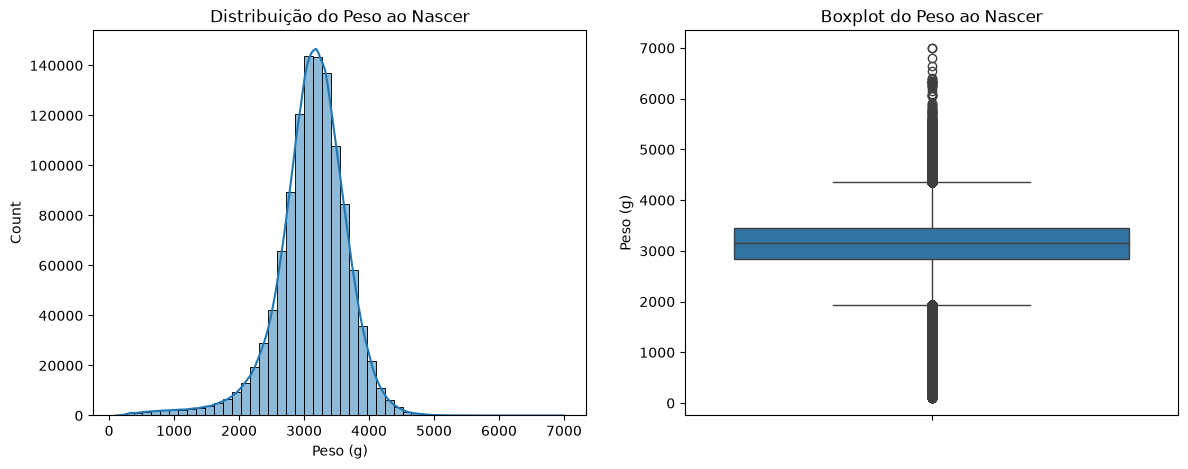

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com curva de densidade
sns.histplot(df['PESO'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Peso ao Nascer')
axes[0].set_xlabel('Peso (g)')

# Boxplot para visualizar outliers
sns.boxplot(y=df['PESO'], ax=axes[1])
axes[1].set_title('Boxplot do Peso ao Nascer')
axes[1].set_ylabel('Peso (g)')

plt.show()

Podemos ver que de fato a média do peso está por volta de 3100 gramas, com valores relativamente concentrados. Entretanto, existe valores para peso inferior a 500g e superior a 6000g, fora da literatura clinica, portanto são dados que devem estar sendo removidos do dataset.

Além disso, podemos ver a proporção de crianças abaixo de 2500g, segundo a taxa nacional, ela deve estar entre 8 a 10%.

In [11]:
# Proporção entre 8 a 10%
round((df['PESO'].shape[0]/ df[df['PESO'] < 2500].shape[0]), 2)

10.02

A proporção de crianças de MG abaixo de 2500g está entre a média nacional.

Verficando se o período de pandemia alterou as distribuições:

In [12]:
# Convertendo a data de nascimento para o tipo datetime
df['DTNASC'] = pd.to_datetime(df['DTNASC'], format='%d%m%Y', errors='coerce')

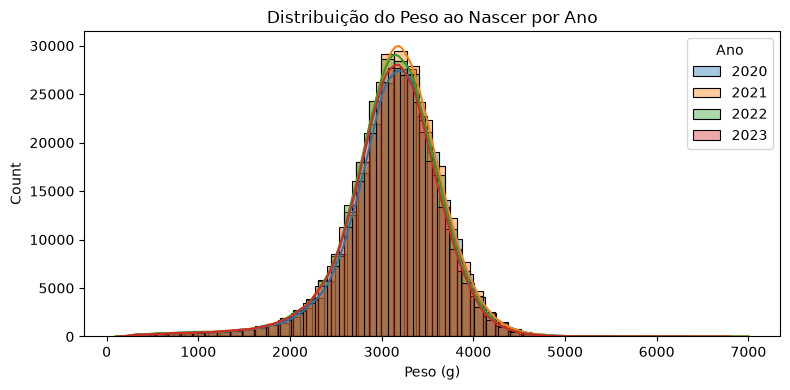

In [13]:
# Desenhando os gráficos
fig, ax = plt.subplots(figsize=(8, 4))

anos = [2020, 2021, 2022, 2023, 2024]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ano, cor in zip(anos, cores):
    dados = df[(df['DTNASC'] >= f'{ano}-01-01') & (df['DTNASC'] <= f'{ano}-12-31')]['PESO']
    sns.histplot(dados, bins=50, kde=True, ax=ax, color=cor, label=str(ano), alpha=0.4)

ax.set_title('Distribuição do Peso ao Nascer por Ano')
ax.set_xlabel('Peso (g)')
ax.legend(title='Ano')

plt.tight_layout()
plt.show()

Pelas sobreposições dos gráficos, as distribuições permaneceram a mesma.

## **Distribuições**

Vamos explorar as distribuições de cada tipo de variável

### Categóricas

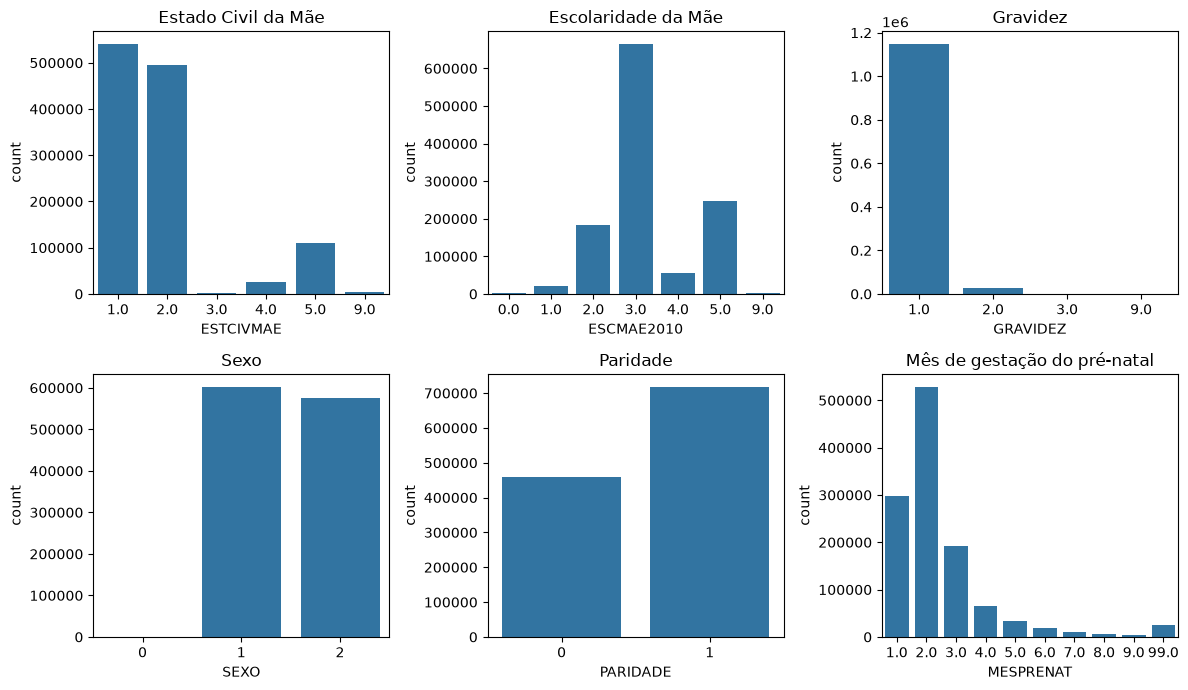

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

sns.countplot(x=df['ESTCIVMAE'], ax=axes[0,0])
axes[0,0].set_title('Estado Civil da Mãe')

sns.countplot(x=df['ESCMAE2010'], ax=axes[0,1])
axes[0,1].set_title('Escolaridade da Mãe')

sns.countplot(x=df['GRAVIDEZ'], ax=axes[0,2])
axes[0,2].set_title('Gravidez')

sns.countplot(x=df['SEXO'], ax=axes[1,0])
axes[1,0].set_title('Sexo')

sns.countplot(x=df['PARIDADE'], ax=axes[1,1])
axes[1,1].set_title('Paridade')

sns.countplot(x=df['MESPRENAT'], ax=axes[1,2])
axes[1,2].set_title('Mês de gestação do pré-natal')

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Estado Civil da Mãe:** Concentração forte em 1 (Solteira) e 2 (Casada), ambas dominam o dataset. 5 (União estável) tem um volume relevante.
- **Escolaridade da Mãe:** Bem definido em 3 (Ensino Médio) com mais de 600 mil registros, seguido por superior completo.
- **Gravidez:** A maior parte concentrada em única. Gravidez múltiplca é uma fração muito pequeno da amostra. É uma classe desbalanceada dentro do dataset.
- **Sexo:** Distribuição esperada, aproximadamente 50% para ambas as categorias.
- **Paridade:** Distribuição bem equilibrada também.
- **Mês de gestação em que iniciou o pré-natal:** Concetração muito forte nos dois primeiros meses, um começo precoce é bem positivo para saúde pública, caindo de forma consistente até o mês 9. Categoria de ignorado (99) bem forte

### Numéricas

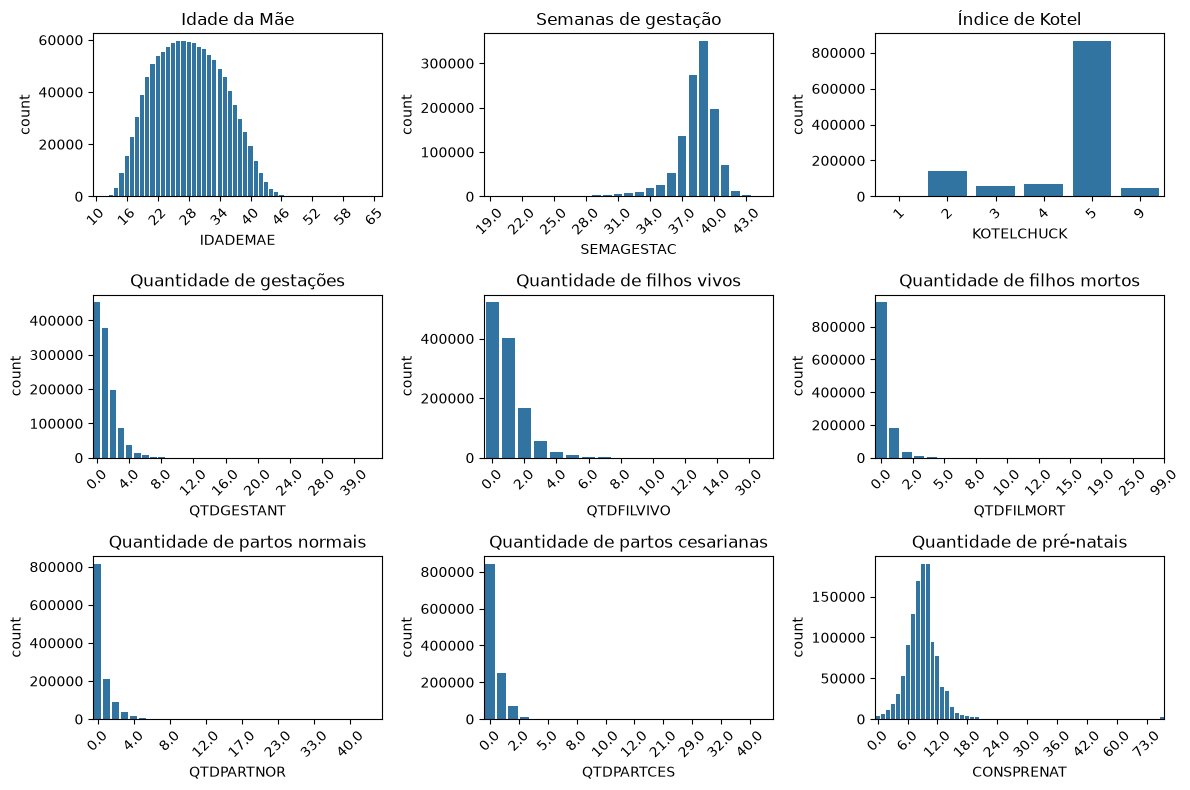

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

colunas_titulos = {
    'IDADEMAE': 'Idade da Mãe',
    'SEMAGESTAC': 'Semanas de gestação',
    'KOTELCHUCK': 'Índice de Kotel',
    'QTDGESTANT': 'Quantidade de gestações',
    'QTDFILVIVO': 'Quantidade de filhos vivos',
    'QTDFILMORT': 'Quantidade de filhos mortos',
    'QTDPARTNOR': 'Quantidade de partos normais',
    'QTDPARTCES': 'Quantidade de partos cesarianas',
    'CONSPRENAT': 'Quantidade de pré-natais',
}

for ax, (coluna, titulo) in zip(axes.flat, colunas_titulos.items()):
    sns.countplot(x=df[coluna], ax=ax)
    ax.set_title(titulo)
    if coluna == 'KOTELCHUCK':
        ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    else:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Idade da Mãe:** Distribuição comportada, formato de sino suavemente assimétrico à direita, com média de 24 à 28 anos, dentro do escopo esperado, avaliar extremos menor que 10 e maior que 65.
- **Semanas de Gestação:** Concentração forte em 37 à 40 semanas, com uma cauda suave até 28. Formato esperado clinicamente.
- **Índice de Kotelchuck:** Concentrado na categoria 5, indica um bom sinal de qualidade assistencial na base.
- **Quantidade de Gestações:** Fortemente concentrado em 0 à 2, padrão esperado. Avaliar valores acima de 15 gestações.
- **Quantidade de Filhos Vivos:** Concentração em 0-1, cauda até 30, avaliar os extremos.
- **Quantidade de Filhos Mortos:** Avaliar valores extremos.
- **Quantidade de Partos Normais/Cesáreos:** Forte concentração em 0 à 1.
- **Quantidade de Consultas Pré-natal:** Distribuição aproximadamente normal, concetrada em 6-9 consultas. Coerente com a recomendação de pré-natal adequado. Avaliar caudas extremas.

## Correlação

Vamos entender como as variáveis se correlacionam entre elas:

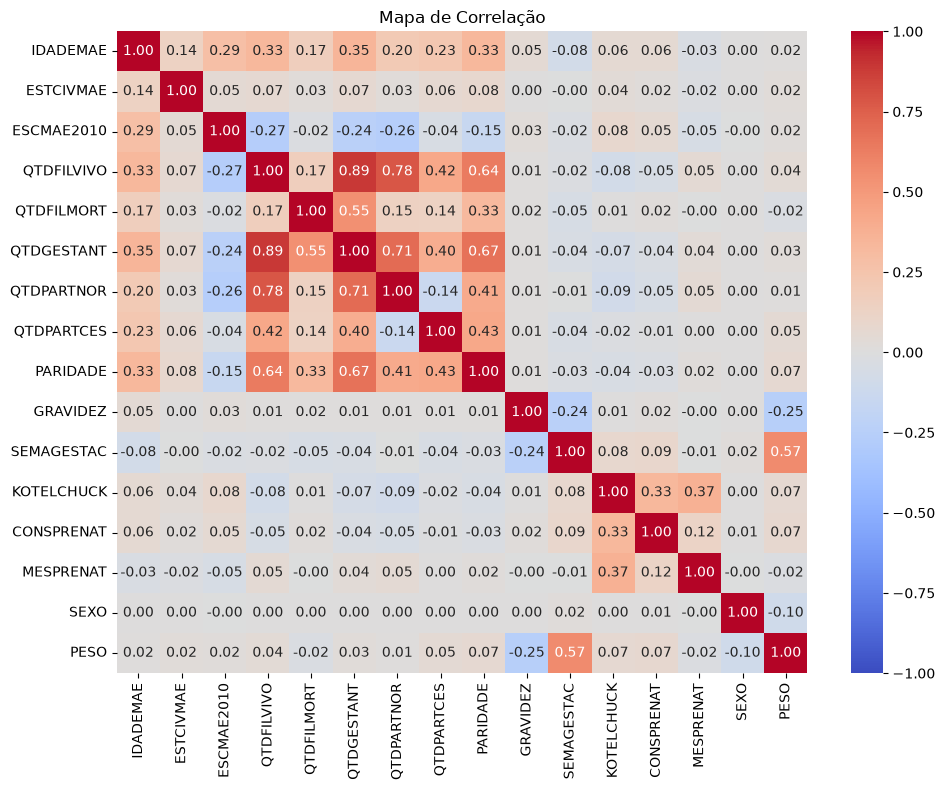

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlação')
plt.tight_layout()
plt.show()

### Relações importantes com o target

- A variável `SEMAGESTAC` tem uma forte relação, confirmando a hipótese qeu a quantidade de semanas tem forte relação com o peso.
- A quantidade de bebês por gestação, medida por `GRAVIDEZ`, se relaciona de forma negativa, portanto o peso individual de cada bebê é menor.
- O `SEXO` também indica uma relação fraca, indicando que meninos nascem pesando mais.
- `GRAVIDEZ` e `SEMAGESTAC`: -0.24, gravidez múltipla tende a nascer mais cedo, coerente com a literatura.

### Multicolinearidade entre as features

- `QTDFILVIVO` e `QTDGESTANT`: 0.89
- `QTDFILVIVO` e `QTDPARTOR`: 0.78
- `QTDGESTANT` e `PARIDADE`: 0.67
- `QTDGESTANT` e `QTDPARTNOR`: 0.71
- `QTDFILVIVO` e `PARIDADE`: 0.64
- `QTDGESTANT` e `QTDFILMORT`: 0.55

Isso era esperado, visto que todas medem quantas vezes essa mulher já passou por gestação/parto, entretando é problemático terem todas juntas no mesmo modelo linear. A decisão é deixar apenas `PARIDADE` e `QTDGESTANT`, ou aplicar PCA para manter todas.

### Demais correlações

- `ESCMAE2010` tem correlação negativa com as variáveis de contagem, `QTDFILVIVO`: -0,27, `QTDGESTANT`: -0,24, `QTDPARTNOR`: -0,26, `PARIDADE`: -0,15, indicando aquilo que é reformaçado pela literatura socioeconômica, mães com mais escolaridade tendem a ter menos filhos. Entretanto, `ESCMAE2010` já carrega parte da informação que essas variáveis de contagem trazem, sendo portanto redundante.
- `KOTELCHUCK` e `MESPRENAT`: 0.37, `KOTELCHUCK` e `CONSPRENAT`: 0.33, o índice é calculado a partir dessas duas variáveis, apresenta portanto uma necessidade de utilizar apenas duas variáveis e não as três.


## Análise bivariada


Assim como feito para cada variável, vamos entender como cada variável fica distribuída em relação ao peso.

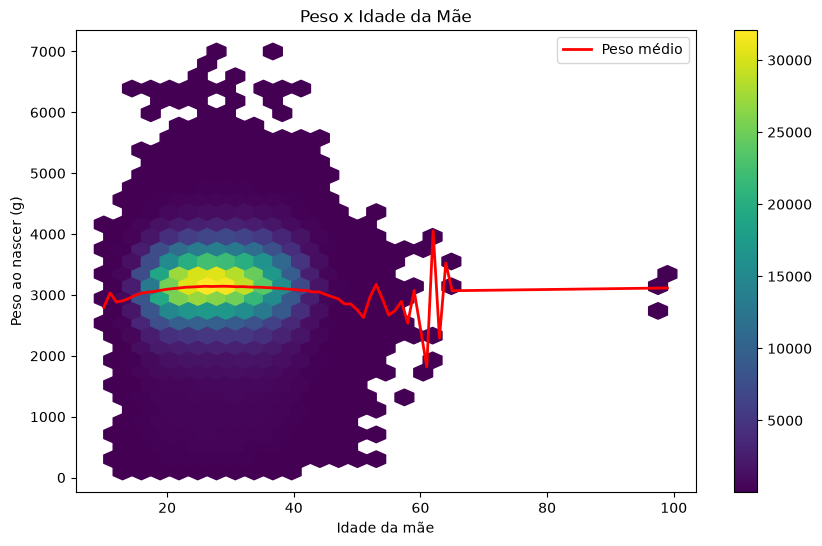

In [17]:

fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(df['IDADEMAE'], df['PESO'], gridsize=30, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax)

# Peso médio por idade (linha de tendência)
media_por_idade = df.groupby('IDADEMAE')['PESO'].mean()
ax.plot(media_por_idade.index, media_por_idade.values, color='red', linewidth=2, label='Peso médio')

ax.set_xlabel('Idade da mãe')
ax.set_ylabel('Peso ao nascer (g)')
ax.set_title('Peso x Idade da Mãe')
ax.legend()
plt.show()

Com a linha peso médio, verificamos a hipotese em U, com o peso crescendo até os 30 anos de forma consistente, mas depois disso fica praticamente dos 30 a 50 anos, sem mostrar de forma clara uma queda, e após 55 anos, a curva vira ruido.

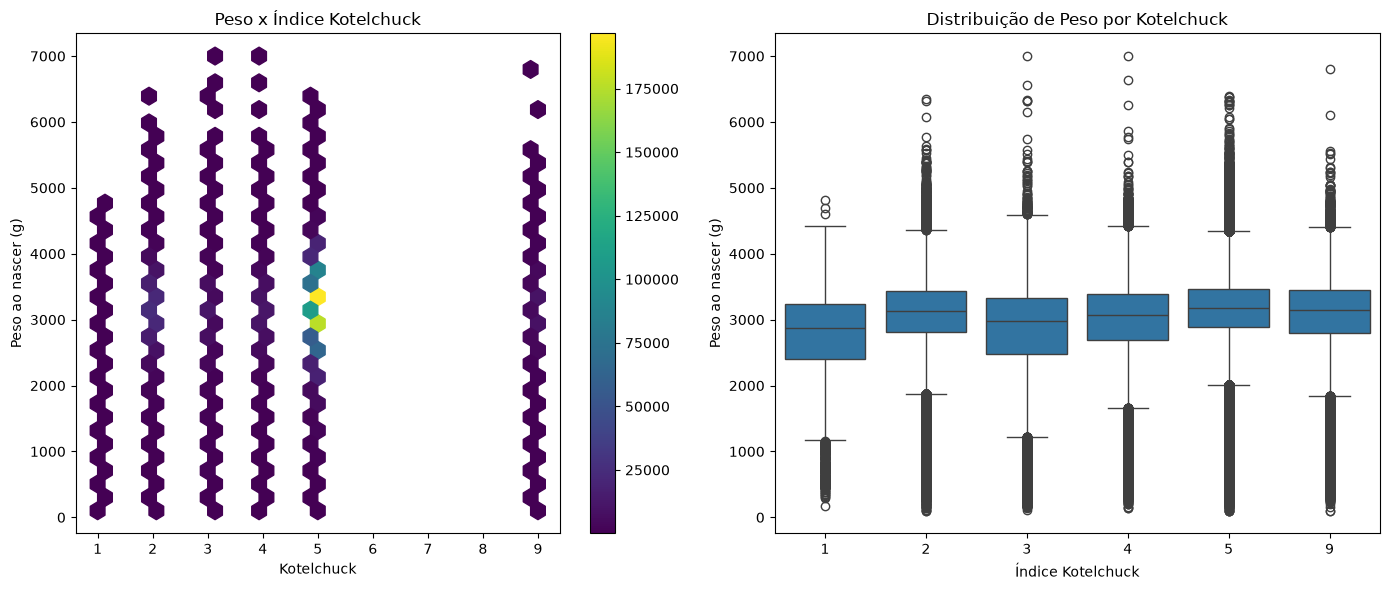

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hexbin
hb = axes[0].hexbin(df['KOTELCHUCK'], df['PESO'], gridsize=30, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0])
axes[0].set_xlabel('Kotelchuck')
axes[0].set_ylabel('Peso ao nascer (g)')
axes[0].set_title('Peso x Índice Kotelchuck')

# Boxplot
sns.boxplot(x='KOTELCHUCK', y='PESO', data=df, ax=axes[1])
axes[1].set_xlabel('Índice Kotelchuck')
axes[1].set_ylabel('Peso ao nascer (g)')
axes[1].set_title('Distribuição de Peso por Kotelchuck')

plt.tight_layout()
plt.show()

A categoria 1, de pior pré-natal, tem a mediana mais baixa entre todas, o que bate com a expectativa, mas a parit da categoria 2 em diante as medianas ficam muito próximas, média entre 3000 e 3200g, até a categoria 5. A dispersão é parecida entre todas as categorias sem redução de variancia esperada nas categorias de pré-natal mais adequado.

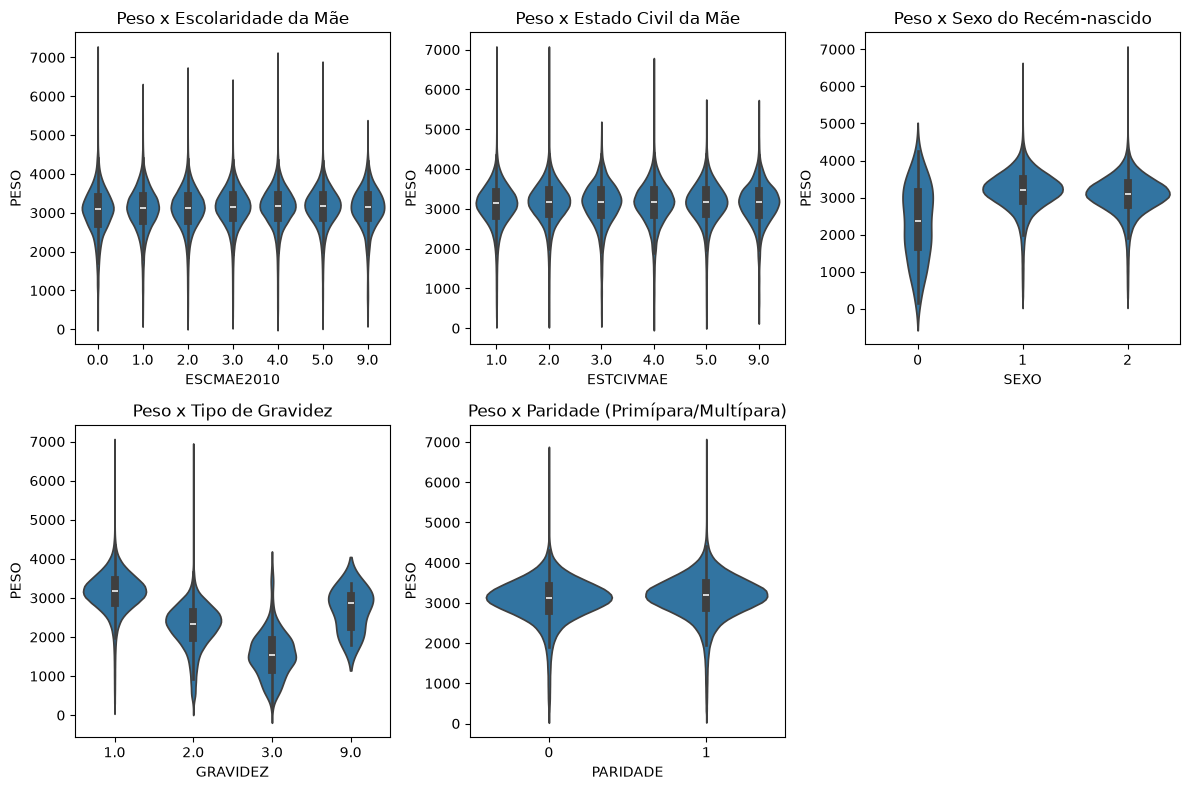

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

colunas_titulos = {
    'ESCMAE2010': 'Escolaridade da Mãe',
    'ESTCIVMAE': 'Estado Civil da Mãe',
    'SEXO': 'Sexo do Recém-nascido',
    'GRAVIDEZ': 'Tipo de Gravidez',
    'PARIDADE': 'Paridade (Primípara/Multípara)'
}

for ax, (coluna, titulo) in zip(axes.flat, colunas_titulos.items()):
    sns.violinplot(x=df[coluna], y=df['PESO'], ax=ax)
    ax.set_title(f'Peso x {titulo}')
    ax.tick_params(axis='x')

# esconde o subplot vazio
for ax in axes.flat[len(colunas_titulos):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Escolaridade da mãe:** Efeito bem sutil do esperado, revelando que escolaridade capture menos informação isolada do que outras variáveis já mostram, ou que o efeito socioeconômico esteja mais concetrado em outras features.  

**Estado civil da mãe:** O padrão se repete, as distribuições quase sobrepostas, sem diferença visual relevante nas medianas, o resultado é um efeito muito sútil.  

**Sexo:** A categoria de idade 0, o que deveria ser ignorado, tem uma distribuição visualmente deslocada para baixo, com mediana bem mais baixa. Isso sugere que pode estar relacionada com partos de maior risco. As categorias 1 e 2 mostram diferença pequena, com masculino levemente mais alto.  

**Tipo de gravidez:** Confirma que existe uma queda do peso quando há gestações com mais de uma criança.  

**Paridade:** Diferença muita pequena entre as duas.  

**Raça/Cor e Raça/Cor da mãe:** Sem diferença visual entre ambas as categorias, remover essas variáveis.


### Investigando resultados ignorados e ambíguos

In [20]:
# Gravidez e sexo
print(df['SEXO'].value_counts())
print(df['GRAVIDEZ'].value_counts())

SEXO
1    602375
2    575624
0       135
Name: count, dtype: int64
GRAVIDEZ
1.0    1148851
2.0      28566
3.0        706
9.0         11
Name: count, dtype: int64


- Decisão: remover valores 0 e 9 de sexo e gravidez.

In [21]:
# proporçao de idade mae maior que 55 e menor que 11
print(df['IDADEMAE'].gt(55).value_counts(normalize=True))
print(df['IDADEMAE'].lt(11).value_counts(normalize=True))

IDADEMAE
False    0.99998
True     0.00002
Name: proportion, dtype: float64
IDADEMAE
False    0.999997
True     0.000003
Name: proportion, dtype: float64


- Decisão: remover valores extremos.

In [22]:
for col, teto in {'QTDFILMORT': 10, 'QTDGESTANT': 15, 'QTDFILVIVO': 15,
                   'QTDPARTNOR': 15, 'QTDPARTCES': 15, 'CONSPRENAT': 20,
                   'IDADEMAE': 55}.items():
    n_acima = (df[col] > teto).sum()
    print(f'{col}: {n_acima} registros acima de {teto} ({n_acima/len(df)*100:.3f}%)')

QTDFILMORT: 43 registros acima de 10 (0.004%)
QTDGESTANT: 54 registros acima de 15 (0.005%)
QTDFILVIVO: 5 registros acima de 15 (0.000%)
QTDPARTNOR: 40 registros acima de 15 (0.003%)
QTDPARTCES: 41 registros acima de 15 (0.003%)
CONSPRENAT: 4807 registros acima de 20 (0.408%)
IDADEMAE: 23 registros acima de 55 (0.002%)


- Decisão: remover valores extremos.

## Feature Engineering

### **Removendo valores extremos e ignorados**

In [23]:
# Condição
condicoes_exclusao = (
    (df['SEXO'] == 0) |
    (df['GRAVIDEZ'] == 9) |
    (df['IDADEMAE'] < 10) | (df['IDADEMAE'] > 55) |
    (df['QTDFILMORT'] > 10) |
    (df['QTDGESTANT'] > 15) |
    (df['QTDFILVIVO'] > 15) |
    (df['QTDPARTNOR'] > 15) |
    (df['QTDPARTCES'] > 15) |
    ((df['CONSPRENAT'] > 30) & (df['CONSPRENAT'].notna())) |
    (df['MESPRENAT'] == 99)
)

# Aplica a remoção
df = df[~condicoes_exclusao].copy()

### **Multicolinearidade**

A variável `QTDGESTANT` contempla a totalidade de gestações, incluindo vivos, mortos e abortos, `QTDFILVIVO` é um subconjunto, vale o mesmo para `QTDFILMORT`, mas conceitualmente diferente indicando risco obstétrico. `QTDPARTNOR` E `QTDPARTCES` são subconjuntos de `QTDFILVIVO` e `PARIDADE` representra `QTDGESTANT` > 0. Portanto, as únicas variáveis realmente relevantes são `QTDGESTANT` por representar a variável mais completa do bloco e `QTDFILMORT` pois representa um sinal de risco clínico específico que `QTDGESTANT` não capta.  

Podemos confirmar por uma análise do VIF:

In [24]:
bloco = ['QTDFILVIVO', 'QTDFILMORT', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'PARIDADE']
X = df[bloco].dropna()

vif = pd.DataFrame()
vif['variavel'] = bloco
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(bloco))]
print(vif)

     variavel        VIF
0  QTDFILVIVO  52.854274
1  QTDFILMORT   9.808993
2  QTDGESTANT  71.303253
3  QTDPARTNOR  20.666750
4  QTDPARTCES   9.948908
5    PARIDADE   3.697104


Aqui, a variável `QTDGESTANT` consegue ser explicada em mais de 90% da variância das demais variaveis, enqanto a `PARIDADE` quase não consegue ser explicada.

In [25]:
bloco = ['QTDFILMORT', 'QTDGESTANT']
X = df[bloco].dropna()

vif = pd.DataFrame()
vif['variavel'] = bloco
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(bloco))]
print(vif)

     variavel       VIF
0  QTDFILMORT  1.701727
1  QTDGESTANT  1.701727


Quando avaliamos o VIF apenas das duas variáveis, encontramos um valor aceitável < 5%. Portanto, vamos permanecer apenas com `QTDGESTANT` e `QTDFILMORT`.

In [26]:
bloco = ['QTDFILVIVO', 'QTDPARTNOR', 'QTDPARTCES', 'PARIDADE']
df = df.drop(columns=bloco)

A mesma lógica aplicada anteriormente deve permanecer ao analisar o índice kotelchuck com as variáveis de `CONSTPRENAT` e `MESPRENAT`, visto que o índice é composto pelas duas, vamos decidir olhando para o valor do VIF:

In [27]:

trio = ['KOTELCHUCK', 'CONSPRENAT', 'MESPRENAT']
X = df[trio].dropna()

vif = pd.DataFrame()
vif['variavel'] = trio
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(trio))]
print(vif)

     variavel        VIF
0  KOTELCHUCK  11.532625
1  CONSPRENAT  12.204535
2   MESPRENAT   2.571756


Com um VIF acima de 5%, vamos ter q escolher eliminar `CONSPRENAT` ou `MESPRENAT`, no caso a escolha se voltou para `CONSPRENAT` visto que carrega menos informação e é mais redundante, VIF final:

In [28]:

trio = ['KOTELCHUCK', 'MESPRENAT']
X = df[trio].dropna()

vif = pd.DataFrame()
vif['variavel'] = trio
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(trio))]
print(vif)

     variavel       VIF
0  KOTELCHUCK  2.401751
1   MESPRENAT  2.401751


In [29]:
# Removendo
df = df.drop(columns='CONSPRENAT')

In [30]:
# Definindo o mes, preenchendo valores com a mediana e criando a temporada
def mes_temporada(mes):
    if mes in [12, 1, 2]:
        return 'V'
    elif mes in [3, 4, 5]:
        return 'O'
    elif mes in [6, 7, 8]:
        return 'I'
    elif mes in [9, 10, 11]:
        return 'P'

df['MES'] = df['DTNASC'].astype(str).str.split('-').str[1].astype(float)
df['ANO'] = df['DTNASC'].astype(str).str.split('-').str[0]
median_mes = df['MES'].median()
df['MES'] = df['MES'].fillna(median_mes).astype(int)
df['TEMPORADA'] = df['MES'].apply(mes_temporada)

# Removendo a data de nascimento
df = df.drop(columns='DTNASC')

In [31]:
# Aplicando o one hot encoding para ESTCIVMAE
df['ESTCIVMAE'] = df['ESTCIVMAE'].replace({9: 3})
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['ESTCIVMAE']])

cols = encoder.get_feature_names_out(['ESTCIVMAE'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['ESTCIVMAE'])

In [32]:
# Aplicando o one hot encoding para GRAVIDEZ
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['GRAVIDEZ']])

cols = encoder.get_feature_names_out(['GRAVIDEZ'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['GRAVIDEZ'])

In [33]:
# Aplicando o one hot encoding para KOTELCHUCK
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['KOTELCHUCK']])

cols = encoder.get_feature_names_out(['KOTELCHUCK'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['KOTELCHUCK'])

In [34]:
# Aplicando stantarscaler a IDADEMAE, SEMAGESTAC, QTDGESTANT e QTDFILMORT
scaler = StandardScaler()
df[['IDADEMAE', 'SEMAGESTAC', 'QTDGESTANT', 'QTDFILMORT']] = scaler.fit_transform(df[['IDADEMAE', 'SEMAGESTAC', 'QTDGESTANT', 'QTDFILMORT']])

## Modelo

Foi adotado o split temporal, então vamos utilizar os dados de treino para os anos de 2020-2023 e testar o modelo com os dados de 2024, pois dessa forma não existe aprendizado de padrão futuro com vazamento de previsão evitando uma maior performance artificialmente.

In [35]:
# Divisão de treino e teste
train = df[df['ANO'].isin(['2020', '2021', '2022', '2023'])]
test = df[df['ANO'] == '2024']

# Separando features e target 
X_train, y_train = train.drop(columns=['PESO']), train['PESO']
X_test, y_test = test.drop(columns=['PESO']), test['PESO']

Criando uma baseline com regressão linear:

In [36]:
model = LinearRegression()

cols = X_train.select_dtypes(include=["float64", "int64"]).columns
X_train_num = X_train[cols]
X_test_num = X_test[cols]

model.fit(X_train_num, y_train)
y_pred = model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"Coeficientes: {dict(zip(X_train_num.columns, model.coef_))}")

MAE: 328.46
RMSE: 428.58
R²: 0.3718
Coeficientes: {'IDADEMAE': np.float64(8.517981480870809), 'ESCMAE2010': np.float64(17.05264584441552), 'QTDFILMORT': np.float64(-26.077598009799704), 'QTDGESTANT': np.float64(47.59243123487798), 'SEMAGESTAC': np.float64(290.1066279714009), 'MESPRENAT': np.float64(-4.338393827505052), 'SEXO': np.float64(-116.7814647962667), 'MES': np.float64(-3.5126316921539176), 'ESTCIVMAE_2.0': np.float64(39.30940775388561), 'ESTCIVMAE_3.0': np.float64(23.790875039280657), 'ESTCIVMAE_4.0': np.float64(23.447673313367275), 'ESTCIVMAE_5.0': np.float64(27.271491249252314), 'GRAVIDEZ_2.0': np.float64(-460.20399331950887), 'GRAVIDEZ_3.0': np.float64(-679.4726204500969), 'KOTELCHUCK_2': np.float64(174.04304479957992), 'KOTELCHUCK_3': np.float64(89.8639815843832), 'KOTELCHUCK_4': np.float64(154.78505155817706), 'KOTELCHUCK_5': np.float64(210.66142150767755), 'KOTELCHUCK_9': np.float64(116.37400254605261)}


Os resultados para o modelo padrão mais simples de regressão é de **0.3718** para o R² e **328.46** para MAE.

### **RIDGE**

In [42]:
# Define os hiperparametros para tuning
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e3, log=True)
    solver = trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sag'])

    model = Ridge(alpha=alpha, solver=solver, random_state=10)
    model.fit(X_train_num, y_train)

    y_pred = model.predict(X_test_num)
    mae = mean_absolute_error(y_test, y_pred)

    return mae

# Inicia a função
study = optuna.create_study(direction='minimize', study_name='ridge_tunig')
study.optimize(objective, n_trials=100, show_progress_bar=False)

# Aplica a função com os melhores hiperparametros
best_params = study.best_params

model = Ridge(**best_params, random_state=10)
model.fit(X_train_num, y_train)

y_pred = model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))
print(f"Coeficientes: {dict(zip(X_train_num.columns, model.coef_))}")

[I 2026-09-07 11:42:52,863] A new study created in memory with name: ridge_tunig
[I 2026-09-07 11:42:53,779] Trial 0 finished with value: 328.46585729198836 and parameters: {'alpha': 621.2718908483171, 'solver': 'svd'}. Best is trial 0 with value: 328.46585729198836.
[I 2026-09-07 11:42:54,623] Trial 1 finished with value: 328.45710565727677 and parameters: {'alpha': 0.08551042547035705, 'solver': 'svd'}. Best is trial 1 with value: 328.45710565727677.
[I 2026-09-07 11:42:54,799] Trial 2 finished with value: 328.45713402501855 and parameters: {'alpha': 0.00038418984017103805, 'solver': 'auto'}. Best is trial 1 with value: 328.45710565727677.
[I 2026-09-07 11:42:55,839] Trial 3 finished with value: 328.4571292722217 and parameters: {'alpha': 0.014636761184277496, 'solver': 'svd'}. Best is trial 1 with value: 328.45710565727677.
[I 2026-09-07 11:42:56,024] Trial 4 finished with value: 328.43850590692 and parameters: {'alpha': 238.9241160321488, 'solver': 'cholesky'}. Best is trial 4 with

MAE: 328.4350411854257
RMSE: 428.5912305166899
R²: 0.3717972498605151
Coeficientes: {'IDADEMAE': np.float64(8.554078107866797), 'ESCMAE2010': np.float64(17.068511454276877), 'QTDFILMORT': np.float64(-25.984783677000742), 'QTDGESTANT': np.float64(47.46466139078451), 'SEMAGESTAC': np.float64(290.5942491072363), 'MESPRENAT': np.float64(-4.185593355914627), 'SEXO': np.float64(-116.73278690533702), 'MES': np.float64(-3.5150612537172763), 'ESTCIVMAE_2.0': np.float64(39.34799679875578), 'ESTCIVMAE_3.0': np.float64(22.18559266375922), 'ESTCIVMAE_4.0': np.float64(22.890157526471537), 'ESTCIVMAE_5.0': np.float64(27.324463026777508), 'GRAVIDEZ_2.0': np.float64(-456.2608718750154), 'GRAVIDEZ_3.0': np.float64(-542.6608115071531), 'KOTELCHUCK_2': np.float64(103.07936457756112), 'KOTELCHUCK_3': np.float64(19.289820401784024), 'KOTELCHUCK_4': np.float64(83.95906716668732), 'KOTELCHUCK_5': np.float64(140.20569572824652), 'KOTELCHUCK_9': np.float64(45.75564862195867)}


### **LASSO**

In [38]:
# Definindo a função de otimização
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000, step=1000)

    model = Lasso(alpha=alpha, max_iter=max_iter, random_state=10)
    model.fit(X_train_num, y_train)

    y_pred = model.predict(X_test_num)
    mae = mean_absolute_error(y_test, y_pred)

    return mae

study = optuna.create_study(direction='minimize', study_name='lasso_tuning')
study.optimize(objective, n_trials=100)

print("Melhores parâmetros:", study.best_params)
print("Melhor MAE:", study.best_value)

# Aplica a função com os melhores hiperparâmetros
best_params = study.best_params

model = Lasso(**best_params, random_state=10)
model.fit(X_train_num, y_train)

y_pred = model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

[I 2026-09-07 08:49:02,043] A new study created in memory with name: lasso_tuning
[I 2026-09-07 08:49:15,256] Trial 0 finished with value: 328.44439313502426 and parameters: {'alpha': 0.0556385336793331, 'max_iter': 2000}. Best is trial 0 with value: 328.44439313502426.
[I 2026-09-07 08:49:52,425] Trial 1 finished with value: 328.4568149404661 and parameters: {'alpha': 0.0004723022747563029, 'max_iter': 5000}. Best is trial 0 with value: 328.44439313502426.
[I 2026-09-07 08:49:55,672] Trial 2 finished with value: 328.4744145028061 and parameters: {'alpha': 0.18982838148261713, 'max_iter': 6000}. Best is trial 0 with value: 328.44439313502426.
[I 2026-09-07 08:50:45,620] Trial 3 finished with value: 328.4570444386786 and parameters: {'alpha': 0.00013053664960008387, 'max_iter': 7000}. Best is trial 0 with value: 328.44439313502426.
[I 2026-09-07 08:51:02,532] Trial 4 finished with value: 328.44888072189053 and parameters: {'alpha': 0.027233381404281765, 'max_iter': 4000}. Best is trial 

Melhores parâmetros: {'alpha': 0.054929428390867695, 'max_iter': 9000}
Melhor MAE: 328.44438631984775
MAE: 328.44438631984775
RMSE: 428.60337617214344
R²: 0.3717616446417167


### **Random Forrest**

In [39]:
# Parametros para otimização
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 18),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 10,
        'n_jobs': -1
    }
    if params['bootstrap']:
        params['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)

    model = RandomForestRegressor(**params)
    model.fit(X_train_num, y_train)

    preds = model.predict(X_test_num)
    mae = mean_absolute_error(y_test, preds)

    return mae


study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=10),
    study_name='rf_birthweight'
)


study.optimize(objective, n_trials=50, timeout=3600, show_progress_bar=True, n_jobs=1)
print('MAE:', study.best_value)
print('Melhores Parametros:', study.best_params)

# Modelo final
best_params = study.best_params
best_params.update({'random_state': 10, 'n_jobs': -1})

final_model = RandomForestRegressor(**best_params)
final_model.fit(X_train_num, y_train)

y_pred = final_model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

[I 2026-09-07 09:08:09,033] A new study created in memory with name: rf_birthweight


Best trial: 0. Best value: 327.546:   2%|▏         | 1/50 [01:33<1:16:02, 93.11s/it, 93.11/3600 seconds]

[I 2026-09-07 09:09:42,145] Trial 0 finished with value: 327.5457337673864 and parameters: {'n_estimators': 350, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 15, 'max_features': 0.7, 'bootstrap': True, 'max_samples': 0.8426799091838986}. Best is trial 0 with value: 327.5457337673864.


Best trial: 0. Best value: 327.546:   4%|▍         | 2/50 [02:55<1:09:36, 87.01s/it, 175.84/3600 seconds]

[I 2026-09-07 09:11:04,877] Trial 1 finished with value: 327.5524468636562 and parameters: {'n_estimators': 400, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 17, 'max_features': 0.7, 'bootstrap': True, 'max_samples': 0.5710850238007634}. Best is trial 0 with value: 327.5457337673864.


...

[I 2026-09-07 10:04:06,693] Trial 34 finished with value: 320.3334544211828 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True, 'max_samples': 0.8467786550566981}. Best is trial 24 with value: 320.3244619448933.


Best trial: 24. Best value: 320.324:  72%|███████▏  | 36/50 [58:03<29:45, 127.53s/it, 3483.28/3600 seconds]

[I 2026-09-07 10:06:12,312] Trial 35 finished with value: 320.348968546754 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True, 'max_samples': 0.9061037599669104}. Best is trial 24 with value: 320.3244619448933.


Best trial: 24. Best value: 320.324:  74%|███████▍  | 37/50 [1:00:30<21:15, 98.11s/it, 3630.22/3600 seconds] 


[I 2026-09-07 10:08:39,260] Trial 36 finished with value: 320.4776346839113 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 0.7, 'bootstrap': True, 'max_samples': 0.845784031879682}. Best is trial 24 with value: 320.3244619448933.
MAE: 320.3244619448933
Melhores Parametros: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True, 'max_samples': 0.8871398437472789}
MAE: 320.3244619448933
RMSE: 418.4695779487279
R²: 0.40111828418110407


### **XGBoost**

In [40]:
# Parametros para otimização
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 10,
        'n_jobs': -1,
        'tree_method': 'hist',
        'early_stopping_rounds': 30
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_num, y_train,
        eval_set=[(X_test_num, y_test)],
        verbose=False
    )

    preds = model.predict(X_test_num)
    mae = mean_absolute_error(y_test, preds)

    return mae


study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=10),
    study_name='xgb_birthweight'
)

study.optimize(objective, n_trials=50, timeout=3600, show_progress_bar=True, n_jobs=1)
print('MAE:', study.best_value)
print('Melhores Parametros:', study.best_params)

# Modelo final
best_params = study.best_params
best_params.update({'random_state': 10, 'n_jobs': -1, 'tree_method': 'hist'})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train_num, y_train)

y_pred = final_model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

[I 2026-09-07 10:10:47,461] A new study created in memory with name: xgb_birthweight
Best trial: 0. Best value: 320.028:   2%|▏         | 1/50 [00:22<18:14, 22.33s/it, 22.33/3600 seconds]

[I 2026-09-07 10:11:09,792] Trial 0 finished with value: 320.02847767984434 and parameters: {'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.08629294202140579, 'subsample': 0.8744019412693059, 'colsample_bytree': 0.7492535061512953, 'min_child_weight': 5, 'gamma': 0.9903143237981199, 'reg_alpha': 0.0699481785242808, 'reg_lambda': 3.32657660618516e-07}. Best is trial 0 with value: 320.02847767984434.


Best trial: 0. Best value: 320.028:   4%|▍         | 2/50 [00:25<08:51, 11.08s/it, 25.54/3600 seconds]

[I 2026-09-07 10:11:12,998] Trial 1 finished with value: 320.35944163660537 and parameters: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.2560221708894264, 'subsample': 0.5019741331639572, 'colsample_bytree': 0.7560961316928883, 'min_child_weight': 17, 'gamma': 3.0626303341469407, 'reg_alpha': 0.03131827670437561, 'reg_lambda': 4.235304245072407e-06}. Best is trial 0 with value: 320.02847767984434.


Best trial: 0. Best value: 320.028:   6%|▌         | 3/50 [00:34<07:59, 10.19s/it, 34.67/3600 seconds]

...

[I 2026-09-07 10:51:26,277] Trial 47 finished with value: 319.85949824763514 and parameters: {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.02026041074411815, 'subsample': 0.732340455418529, 'colsample_bytree': 0.8651577086637425, 'min_child_weight': 8, 'gamma': 4.13357340895154, 'reg_alpha': 0.08449442583712932, 'reg_lambda': 8.429460605600502e-06}. Best is trial 31 with value: 319.7634913335738.


Best trial: 31. Best value: 319.763:  98%|█████████▊| 49/50 [40:53<00:15, 15.98s/it, 2453.57/3600 seconds]

[I 2026-09-07 10:51:41,031] Trial 48 finished with value: 319.8407748299622 and parameters: {'n_estimators': 750, 'max_depth': 8, 'learning_rate': 0.030715592107985957, 'subsample': 0.5063817651245657, 'colsample_bytree': 0.9116567250730176, 'min_child_weight': 11, 'gamma': 3.270841192678878, 'reg_alpha': 8.133358916139326, 'reg_lambda': 1.2211292663075799e-07}. Best is trial 31 with value: 319.7634913335738.


Best trial: 31. Best value: 319.763: 100%|██████████| 50/50 [41:20<00:00, 49.61s/it, 2480.46/3600 seconds]


[I 2026-09-07 10:52:07,921] Trial 49 finished with value: 319.82241769784775 and parameters: {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.023640090715399346, 'subsample': 0.7076180312864166, 'colsample_bytree': 0.9754451975277532, 'min_child_weight': 12, 'gamma': 3.9487266540435644, 'reg_alpha': 0.018182636293408397, 'reg_lambda': 1.7821686418537425e-05}. Best is trial 31 with value: 319.7634913335738.
MAE: 319.7634913335738
Melhores Parametros: {'n_estimators': 550, 'max_depth': 7, 'learning_rate': 0.04640297247061708, 'subsample': 0.6845455551831829, 'colsample_bytree': 0.9997929109808142, 'min_child_weight': 14, 'gamma': 3.7746261026473658, 'reg_alpha': 7.044435952056339e-07, 'reg_lambda': 0.017846814262640065}
MAE: 319.8938076169389
RMSE: 417.97186905407807
R²: 0.40254200297796305


### **LightGBM**

In [41]:
# Parametros para otimização
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 10,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_num, y_train,
        eval_set=[(X_test_num, y_test)],
        callbacks=[
            lgb.log_evaluation(period=0),
            lgb.early_stopping(stopping_rounds=30, verbose=False)
        ]
    )

    preds = model.predict(X_test_num)
    mae = mean_absolute_error(y_test, preds)

    return mae


study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=10),
    study_name='lgbm_birthweight'
)

study.optimize(objective, n_trials=50, timeout=3600, show_progress_bar=True, n_jobs=1)
print('MAE:', study.best_value)
print('Melhores Parametros:', study.best_params)

# Modelo final
best_params = study.best_params
best_params.update({'random_state': 10, 'n_jobs': -1, 'verbosity': -1})

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(X_train_num, y_train)

y_pred = final_model.predict(X_test_num)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

[I 2026-09-07 10:52:30,779] A new study created in memory with name: lgbm_birthweight
  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Max\OneDrive\Documentos\Projeto\SINASC-BirthWeight\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
Best trial: 0. Best value: 319.931:   2%|▏         | 1/50 [00:09<07:40,  9.40s/it, 9.40/3600 seconds]c:\Users\Max\OneDrive\Documentos\Projeto\SINASC-BirthWeight\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-09-07 10:52:40,179] Trial 0 finished with value: 319.9308213359343 and parameters: {'n_estimators': 700, 'max_depth': 3, 'num_leaves': 86, 'learning_rate': 0.12766567050674044, 'subsample': 0.7492535061512953, 'colsample_bytree': 0.6123983227654238, 'min_child_samples': 24, 'reg_alpha': 0.0699481785242808, 'reg_lambda': 3.32657660618516e-07}. Best is trial 0 with value: 319.9308213359343.


Best trial: 0. Best value: 319.931:   4%|▍         | 2/50 [00:19<08:02, 10.04s/it, 19.90/3600 seconds]c:\Users\Max\OneDrive\Documentos\Projeto\SINASC-BirthWeight\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-09-07 10:52:50,674] Trial 1 finished with value: 322.3298608342135 and parameters: {'n_estimators': 250, 'max_depth': 9, 'num_leaves': 122, 'learning_rate': 0.010135194048459749, 'subsample': 0.7560961316928883, 'colsample_bytree': 0.9063104808260567, 'min_child_samples': 63, 'reg_alpha': 0.03131827670437561, 'reg_lambda': 4.235304245072407e-06}. Best is trial 0 with value: 319.9308213359343.


Best trial: 2. Best value: 319.769:   6%|▌         | 3/50 [00:40<11:32, 14.73s/it, 40.21/3600 seconds]c:\Users\Max\OneDrive\Documentos\Projeto\SINASC-BirthWeight\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

[I 2026-09-07 11:00:34,530] Trial 47 finished with value: 319.7516059890762 and parameters: {'n_estimators': 600, 'max_depth': 10, 'num_leaves': 82, 'learning_rate': 0.019726415928548464, 'subsample': 0.6132579829887246, 'colsample_bytree': 0.973286036946815, 'min_child_samples': 38, 'reg_alpha': 0.36134096695623125, 'reg_lambda': 1.0999200796171722e-05}. Best is trial 29 with value: 319.7202199172191.


Best trial: 29. Best value: 319.72:  98%|█████████▊| 49/50 [08:12<00:12, 12.33s/it, 492.16/3600 seconds]c:\Users\Max\OneDrive\Documentos\Projeto\SINASC-BirthWeight\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[I 2026-09-07 11:00:42,940] Trial 48 finished with value: 320.09100805272544 and parameters: {'n_estimators': 550, 'max_depth': 4, 'num_leaves': 41, 'learning_rate': 0.034777243172865714, 'subsample': 0.7670738536315119, 'colsample_bytree': 0.831421287647304, 'min_child_samples': 30, 'reg_alpha': 0.027563509836058587, 'reg_lambda': 3.223094480483038e-05}. Best is trial 29 with value: 319.7202199172191.


Best trial: 29. Best value: 319.72: 100%|██████████| 50/50 [08:25<00:00, 10.11s/it, 505.69/3600 seconds]


[I 2026-09-07 11:00:56,469] Trial 49 finished with value: 319.7389427499958 and parameters: {'n_estimators': 700, 'max_depth': 9, 'num_leaves': 61, 'learning_rate': 0.020405511681329612, 'subsample': 0.7001825769470503, 'colsample_bytree': 0.9258261865983674, 'min_child_samples': 9, 'reg_alpha': 1.250128340842676, 'reg_lambda': 3.342292286898e-06}. Best is trial 29 with value: 319.7202199172191.
MAE: 319.7202199172191
Melhores Parametros: {'n_estimators': 650, 'max_depth': 11, 'num_leaves': 39, 'learning_rate': 0.10489469883536381, 'subsample': 0.7064340740384062, 'colsample_bytree': 0.8869044798868554, 'min_child_samples': 23, 'reg_alpha': 8.28401337704598, 'reg_lambda': 5.237827592172567e-08}
MAE: 319.9908142035465
RMSE: 418.0875595841269
R²: 0.40221121613139177


## Comparativos e Analise Redisual

In [44]:
resultados = [
    {'modelo': 'Regressão Linear', 'mae': 328.46, 'rmse': 428.58, 'r2': 0.3718},
    {'modelo': 'Ridge', 'mae': 328.43, 'rmse': 428.59, 'r2': 0.37},
    {'modelo': 'Lasso', 'mae': 328.44, 'rmse': 428.60, 'r2': 0.37},
    {'modelo': 'Random Forest', 'mae': 320.32, 'rmse': 418.46, 'r2': 0.40},
    {'modelo': 'XGBoost', 'mae': 319.89, 'rmse': 417.97, 'r2': 0.40},
    {'modelo': 'LightGBM', 'mae': 319.99, 'rmse': 418.08, 'r2': 0.40},
]

tabela = pd.DataFrame(resultados).sort_values('rmse')
print(tabela)

             modelo     mae    rmse      r2
4           XGBoost  319.89  417.97  0.4000
5          LightGBM  319.99  418.08  0.4000
3     Random Forest  320.32  418.46  0.4000
0  Regressão Linear  328.46  428.58  0.3718
1             Ridge  328.43  428.59  0.3700
2             Lasso  328.44  428.60  0.3700


Os seis modelos obtiveram desempenho semelhante, com o RMSE entre 417,97 e 428,6 e R² entre 0,37 e 0,4. Os modelos de árvore, XGBoost, LightGBM e RandomForest superaram os lineares, capturando relações não-lineares. Os modelos da classe lineares tiveram desempenho semelhante, visto que a regularização não trouxe ganho após tratamento para multicolinearidade realizado durante a etapa de feature engineering. **XGBoost** foi o melhor entre os três de árvore, portanto, será o modelo aplicado.

In [45]:
# residuos
residuos = y_test - y_pred 

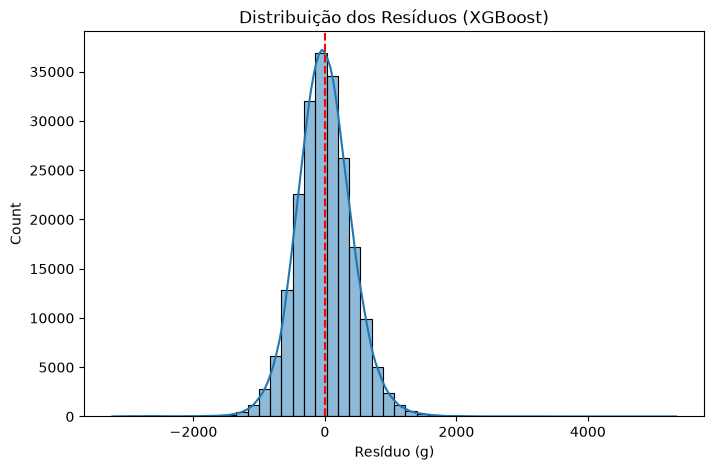

Média do resíduo: -9.04
Desvio padrão: 428.50


In [47]:
# Distribuição
plt.figure(figsize=(8, 5))
sns.histplot(residuos, kde=True, bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribuição dos Resíduos (XGBoost)')
plt.xlabel('Resíduo (g)')
plt.show()

print(f'Média do resíduo: {residuos.mean():.2f}')
print(f'Desvio padrão: {residuos.std():.2f}')

Assim como o esperado, a distribuição de assemelha a normal, centrada no zero, sem viés de direção.

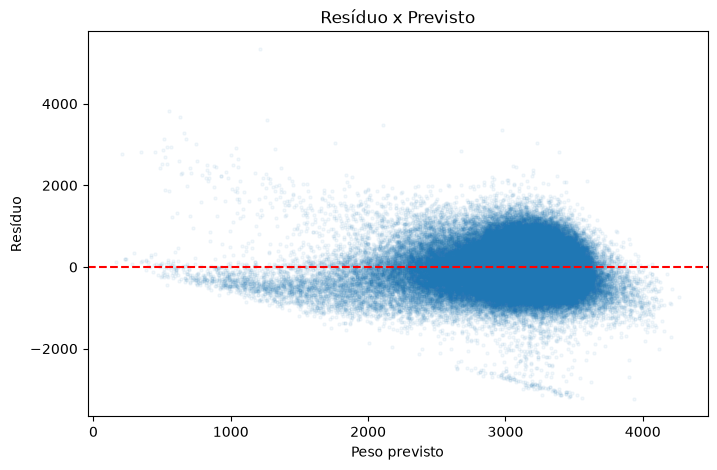

In [54]:
# residuos e valor previsto
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.05, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Peso previsto')
plt.ylabel('Resíduo')
plt.title('Resíduo x Previsto')
plt.show()

O gráfico revela um padrão de regressão à média, nos valores previstos abaixo de 1500g, os resíduos se concentram, na maioria dos casos, acima de zero, indicando que o modelo tende a prever um peso maior do que o real, subestimando o risco, já nos valores previstos entre 3500 e 4000g, os resíduos aparecem mais concentrados abaixo de zero, indicando superestimação. O gráfico também mostra heterocedasticidade, com dispersão mais estreita na faixa central e mais ampla nos extremos.

In [50]:
bins = [0, 1500, 2500, 3000, 3500, 4000, 7000]
labels = ['<1500 (muito baixo)', '1500-2500 (baixo)', '2500-3000', '3000-3500', '3500-4000', '>4000']

faixa_peso = pd.cut(y_test, bins=bins, labels=labels)

erro_por_faixa = pd.DataFrame({'faixa': faixa_peso, 'residuo': residuos, 'erro_abs': residuos.abs()})
resumo = erro_por_faixa.groupby('faixa', observed=True)['erro_abs'].agg(['mean', 'std', 'count'])
print(resumo)

                           mean         std  count
faixa                                             
<1500 (muito baixo)  806.532959  601.570250   3187
1500-2500 (baixo)    549.551521  304.989309  19253
2500-3000            318.415110  199.284519  57879
3000-3500            179.516258  157.128084  89030
3500-4000            448.284672  222.320762  37893
>4000                931.499732  300.803469   5830


O erro médio absoluto do modelo aumenta conforme os valores se afastam da faixa mais comum ao nascer. Na região central, o erro fica apenas em 179,5g e depois sobe para 549,6g na faixa de baixo peso e cha a 806,5g nos casos de peso muito baixo, mais de quatro vezes o erro no centro da distribuição. O modelo é bastante preciso para a maioria dos nascimentos, mas perde confiabilidade justamente no grupo mais critico e relevante, nos bebês com risco de baixo peso.

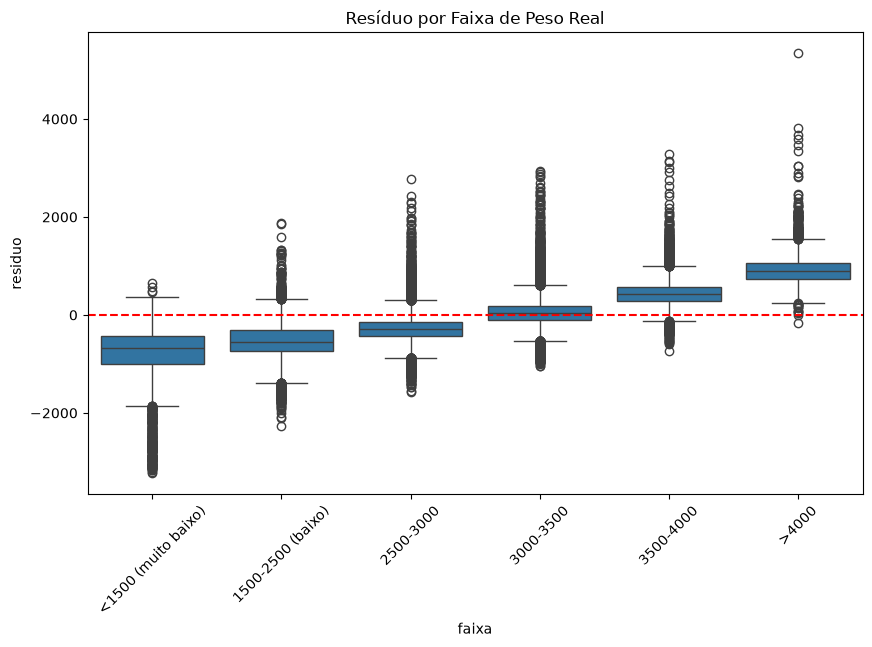

In [51]:
# Boxplot do residuo
plt.figure(figsize=(10, 6))
sns.boxplot(data=erro_por_faixa, x='faixa', y='residuo')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.title('Resíduo por Faixa de Peso Real')
plt.show()

As faixas de peso real mais baixo, a mediana do resíduo é negativa, o que significa que o modelo superestima o peso desses bebês, prevê um valor maior do que o real, atenuando a gravidade do baixo peso. O padrão se invere conforme as faixas de peso vão aumentando, indicando que o modelo passa a subestimar os pesos dos bebês mais pesados. Além da mediana deslocada, a dispersão também é maior em faixas mais extremas do que a faixa central, confirmando que o modelo que erra mais nos extremos.

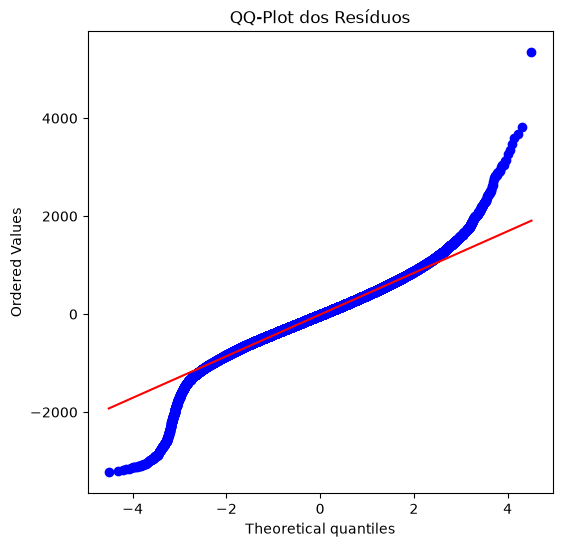

In [53]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=ax)
plt.title('QQ-Plot dos Resíduos')
plt.show()

O QQ-plot mostra que os residuos não seguem uma distribuição normal, com foco nas caudas, a parte central do gráfico acompanha a linha vermelha de referência, mas ambas as extremidades ficam acima da linha ou abaixo. Esse formato indica que o modelo tem mais dificuldade e maior variabilidade de erro justamente nos extremos de peso.

In [ ]:
y_test_bin = (y_test < 2500).astype(int)
y_score = -y_pred

pr_auc = average_precision_score(y_test_bin, y_score)
print(f'PR-AUC (corte 2500g): {pr_auc:.4f}')

PR-AUC (corte 2500g): 0.5989


O valor do PR-AUC proximo de 0,6 era um valor previsto, o modelo foi otimizado para minimizar o erro quadrático médio e não para discriminar bem o corte de 2500g.

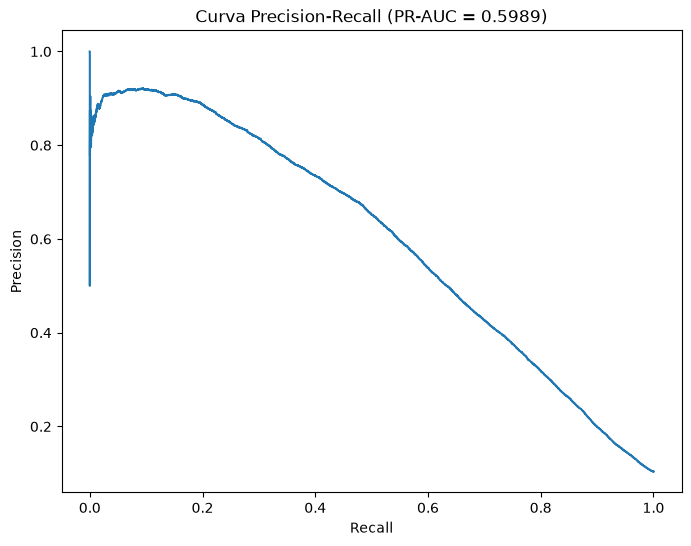

In [56]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test_bin, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Curva Precision-Recall (PR-AUC = {pr_auc:.4f})')
plt.show()

O modelo tem valor real em identificar os casos de risco mais evidentes com maior confiabilidade, mas pode ser usado sem complementação.